In [24]:
from pathlib import Path
rootdir = Path("../../../..").resolve()
import sys
sys.path.insert(0, str(rootdir) )

import numpy as np
import gemmi

In [ ]:
from xaidar.data.molecModels import ( flatten_pdb, get_pdb_stats, loadPDB,
                                     sele_pdb, sele_AA, sele_closest_Chain, sele_Lig,
                                      get_res_CoM, sele_closest_res, structAlign, )

In [3]:
# 1. Loading Fragalyis data Root Directory
rootdir = Path("../../../..").resolve()
rootProjDir = rootdir / "data/ev2a/fragalysis"
rawdataDir = rootProjDir / "01-concatDir/aligned_files"
refProjDir = rootProjDir / "02-chemofint/reference"

## Get Active Site Coordinates

In [27]:
# Reference Protein Active Site
ref_pdb = gemmi.read_pdb( refProjDir.joinpath("A0926a.pdb").__str__() )
# Looked at pdb content and found that there are two different chains, but only one ligand in one chain
# get_pdb_stats(ref_pdb)
# Looked at piperidine files, and they all mostly align with the ref chain that is closest to ligand
# print(type( get_res_CoM( flatten_pdb( sele_pdb( ref_pdb, sele_Lig),  "residue") ) ) )
# get_pdb_stats( sele_pdb( ref_pdb, sele_AA) )

ref_lig = sele_pdb( ref_pdb, sele_Lig)
ref_lig_CoM = get_res_CoM( flatten_pdb( ref_lig,  "residue") )
# print( ref_lig_CoM )

ref_prot = sele_pdb( sele_pdb( ref_pdb, sele_AA), sele_closest_Chain, ref_lig_CoM )
ref_prot[0]["B"].name = "A"
ref_prot_CoM = np.array( ref_prot[0].calculate_center_of_mass().tolist()) 
# print( np.array( ref_prot[0].calculate_center_of_mass().tolist()) )

# get_pdb_stats( ref_prot )

### Get Protein Closest to The Reference protein

In [78]:
database = dict()
for dataset in rawdataDir.iterdir():
    if dataset.is_dir():
        dataset_name = dataset.name
        database[dataset_name] = {"protein":None, "ligand": None, "waters": None, "rmsd": None}
        
        dataset_pdb = gemmi.read_pdb( dataset.joinpath("{}.pdb".format( dataset_name ) ).__str__() )
        
        dataset_prot = sele_pdb( sele_pdb(dataset_pdb, sele_AA), sele_closest_Chain, ref_prot_CoM) 
        dataset_prot_CoM = np.array( dataset_prot[0].calculate_center_of_mass().tolist() )
        database[dataset_name]["protein"] = dataset_prot

        dataset_lig = sele_pdb( sele_pdb( dataset_pdb, sele_Lig), sele_closest_res, dataset_prot_CoM)
        database[dataset_name]["ligand"] = dataset_lig

        rmsd = structAlign( ref_prot, dataset_prot).calc_rmsd().rmsd
        database[dataset_name]["rmsd"] = round( rmsd, 3) 
        if rmsd > 5:
            transform = structAlign( ref_prot, dataset_prot).calc_transform().transform
            aligned_prot = structAlign( None, dataset_prot).apply_transform( transform).aligned_prot
            aligned_lig = structAlign( None, dataset_lig).apply_transform( transform).aligned_prot
            new_rmsd = structAlign( ref_prot, aligned_prot).calc_rmsd().rmsd
            database[dataset_name]["protein"] = aligned_prot
            database[dataset_name]["ligand"] = aligned_lig
            database[dataset_name]["rmsd"] = round( new_rmsd, 3) 


        # print(database[dataset_name]["rmsd"])
    # break
        

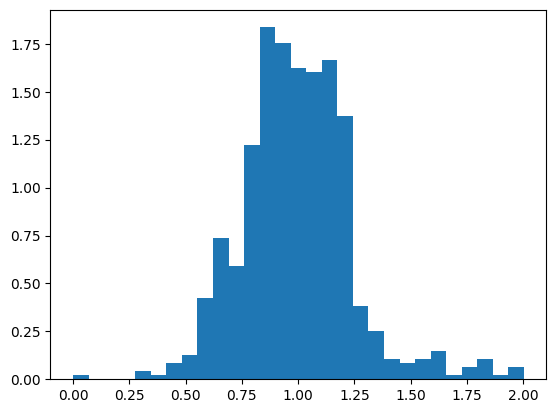

In [ ]:
_, _, _, rmsd_lst = zip(   *[ tuple( dataset.values()) for dataset in database.values() ] )
import matplotlib.pyplot as plt

plt.hist( rmsd_lst, bins = "auto", density = True)
plt.show()
# np.array(rmsd_lst)

In [39]:
print( database.__len__() )
# for value in  database["A0428a"].values():
#     get_pdb_stats(value)
# # print( database["A0428a"])


686


In [99]:
oneConformer_dataset_names =  [ dataset for dataset in database.keys() if [v[:-1] for v in database.keys()].count(dataset[:-1]) == 1]
oneConformer_datasets = { dataset_name : content for dataset_name, content in database.items() if dataset_name in oneConformer_dataset_names }
oneConf_prots, oneConf_ligs, _, _ = zip(   *[ tuple( dataset.values()) for dataset in oneConformer_datasets.values() ] )

# for lig in oneConf_ligs:
#     print(gemmi.Position( *get_res_CoM( flatten_pdb(lig, "residue")).flatten() ).dist(gemmi.Position( *ref_lig_CoM.flatten() )) )
#     break
lig_distances = [ gemmi.Position( *get_res_CoM( flatten_pdb(lig, "residue")).flatten() 
                ).dist(gemmi.Position( *ref_lig_CoM.flatten() )) for lig in oneConf_ligs]

nonactivesite_ligs = [ idx for idx, dist in enumerate(lig_distances) if dist > 15 ]
nonactivesite_prots = [ oneConf_prots[idx] for idx in nonactivesite_ligs ]
print( "Number of Unique One Conformer Proteins with Ligands 20 A away from Ref Piperidine Active Site: " \
"{}".format( nonactivesite_ligs.__len__() ) )


Number of Unique One Conformer Proteins with Ligands 20 A away from Ref Piperidine Active Site: 35
